# One-Site Binding: Association and Dissociation Simulation

This notebook simulates and plots one-site association and dissociation traces for multiple ligand concentrations.

In [5]:
import numpy as np
from pykingenie.utils.signal_surface import (
    one_site_association_analytical,
    one_site_dissociation_analytical,
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Package Functions Used

This notebook uses pykingenie package utilities directly:
- one_site_association_analytical
- one_site_dissociation_analytical
- plot_traces

In [6]:
# Kinetic parameters
Kd = 0.125           # μM
koff = 0.005          # 1/s
smax = 5.0           # response units
s0 = 0.0

# Log-spaced concentrations (μM)
concentrations = np.logspace(-3, 0, 6)
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

In [7]:
assoc_xs, assoc_ys, assoc_legends = [], [], []
disso_xs, disso_ys, disso_legends = [], [], []
colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

for conc in concentrations:
    assoc = one_site_association_analytical(
        t_assoc, s0=s0, s_max=smax, k_off=koff, Kd=Kd, A=conc, t0=0
    )
    disso = one_site_dissociation_analytical(t_disso, s0=assoc[-1], k_off=koff, t0=0)

    assoc_xs.append(t_assoc)
    assoc_ys.append(assoc)
    assoc_legends.append(f"{conc:.3g} uM")

    disso_xs.append(t_disso)
    disso_ys.append(disso)
    disso_legends.append(f"{conc:.3g} uM")

show = [True] * len(concentrations)

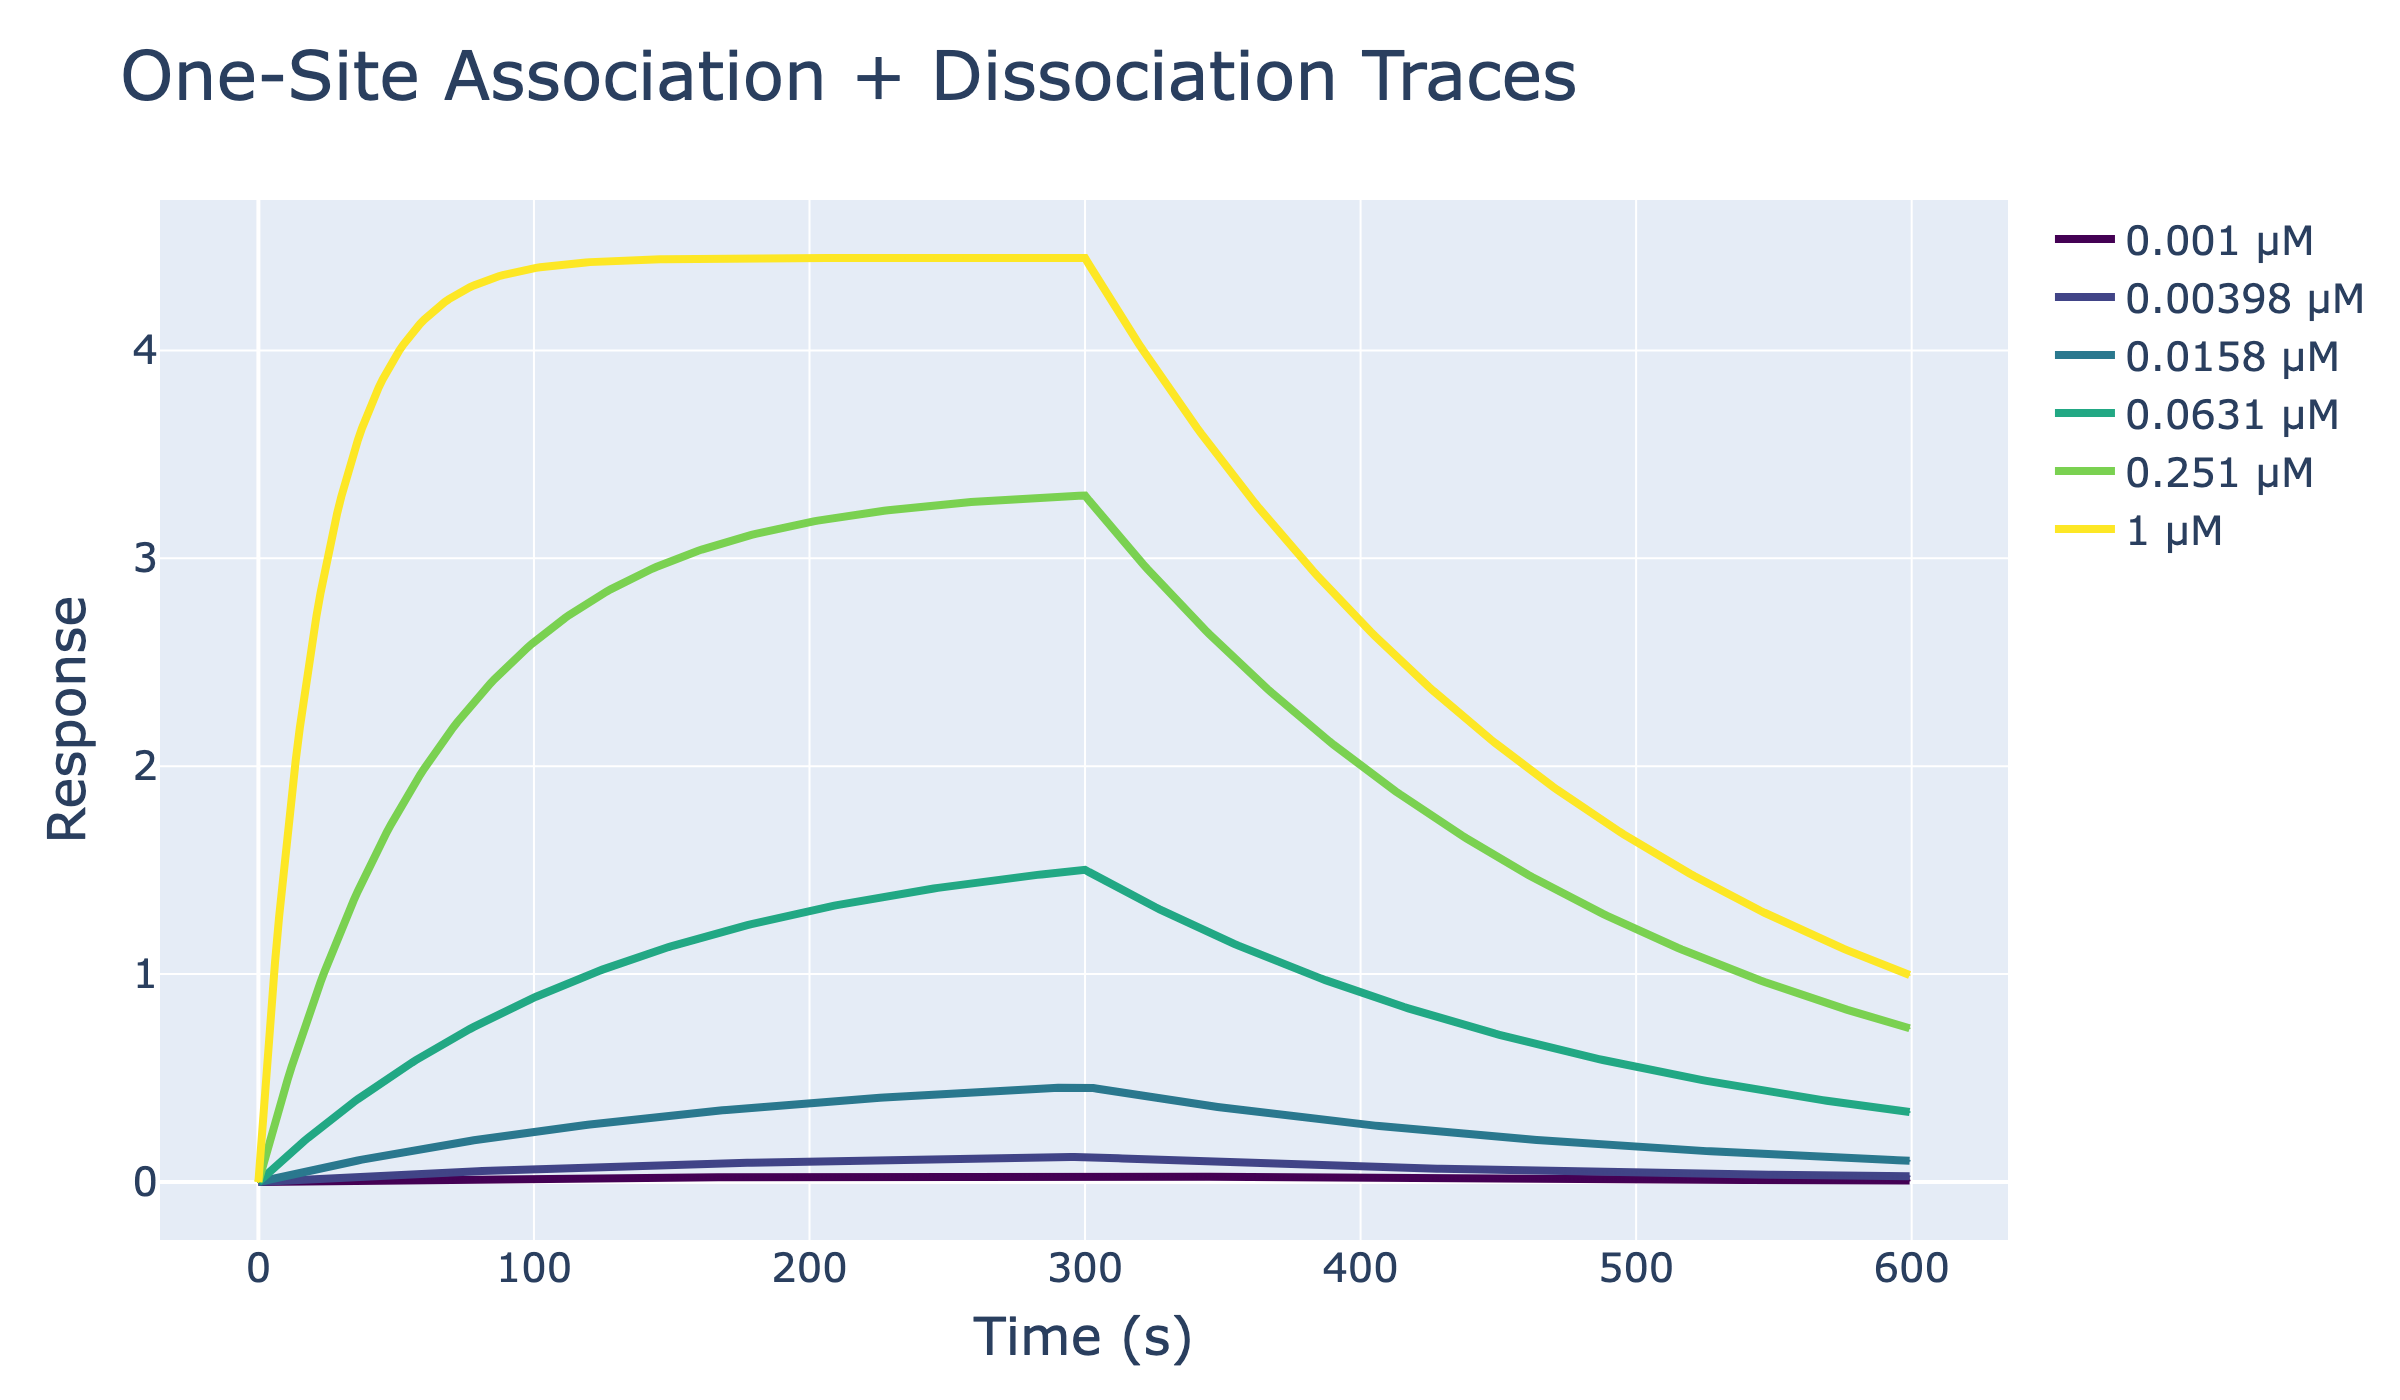

In [8]:
combined_xs, combined_ys, combined_legends = [], [], []

for i, conc in enumerate(concentrations):
    t_disso_shifted = t_disso + t_assoc[-1]
    combined_xs.append([assoc_xs[i], t_disso_shifted])
    combined_ys.append([assoc_ys[i], disso_ys[i]])
    combined_legends.append(f"{conc:.3g} µM")

fig_combined = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=combined_legends,
    colors=colors[:len(concentrations)],
    show=show,
    marker_size=1,
    line_width=4,
)

fig_combined.update_layout(
    title={"text": "One-Site Association + Dissociation Traces", "font": {"size": 34}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 22},
    legend={"font": {"size": 20}},
)

fig_combined.update_xaxes(title_font={"size": 26}, tickfont={"size": 20})
fig_combined.update_yaxes(title_font={"size": 26}, tickfont={"size": 20})

# Static image output is GitHub-friendly
show_plotly_static(fig_combined)